In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 97.9 MB/s eta 0:00:00
  Attempting uninstall: autograd
    Found existing installation: autograd 1.9.1
    Uninstalling autograd-1.9.1:
      Successfully uninstalled autograd-1.9.1


#Pennylane 101

1. Quantum functions and QNodes
2. Devices
3. Templates
4. Debugging tips

In [2]:
#import your new favorite library
import pennylane as qp
qp.about()
#Go to pennylane.ai to see if you're using the most recent stable version

Name: pennylane
Version: 0.45.1
Summary: PennyLane is a cross-platform Python library for quantum computing, quantum machine learning, and quantum chemistry. Train a quantum computer the same way as a neural network.
Home-page: 
Author: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Platform info:           Linux-6.6.122+-x86_64-with-glibc2.35
Python version:          3.12.13
Numpy version:           2.0.2
Scipy version:           1.16.3
JAX version:             0.7.2
Catalyst version:        None
Installed devices:
- default.clifford (pennylane-0.45.1)
- default.gaussian (pennylane-0.45.1)
- default.mixed (pennylane-0.45.1)
- default.qubit (pennylane-0.45.1)
- default.qutrit (pennylane-0.45.1)
- default.qutrit.mixed (pennylane-0.45.1)
- default.tensor (pennylane-0.45.1)
- null.qubit (pennylane-0.45.1)
- reference.qubit (pennylane-0.45.1)
- lightning.qubit (pennylane_lightning-0.45.0)


#Quantum functions and QNodes
A quantum function is just a Python function that includes quantum gates and a measurement.

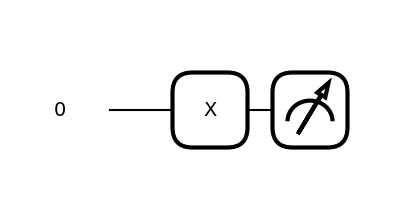

In [3]:
#This is a quantum function
def circuit():
  qp.X(wires=0)
  return qp.probs()

qp.draw_mpl(circuit)();


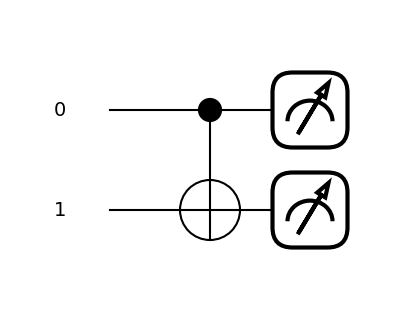

In [4]:
#This is also a quantum function
def circuit2():
  qp.CNOT(wires=[0,1])
  return qp.probs()

qp.draw_mpl(circuit2)();


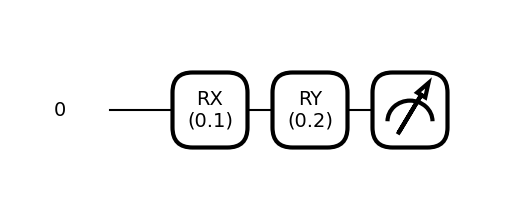

In [6]:
#This us a quantum function where the gates take parameters
def circuit3(x,y):
  qp.RX(x, wires=0)
  qp.RY(y, wires=0)
  return qp.probs()

qp.draw_mpl(circuit3, decimals=1)(0.1,0.2);


QNodes allow you to run your quantum function on a specific device(simulator or actual quantum hardware)

Tip: Not everything needs to be a qnode, sometimes quantum functions are enough.

In [18]:
# device
dev = qp.device("default.qubit")

# This is a qnode (this the preferred way to way to create a qnode)
@qp.qnode(dev)
def circuit3(x,y):
  qp.RX(x, wires=0)
  qp.RY(y, wires=0)
  return qp.probs()

# This is also a qnode
qnode1 = qp.QNode(circuit2, dev)

# Run your circuit by simply calling the function
#circuit3(0.1,0.2)
qnode1()

array([1., 0., 0., 0.])

The output tells us that there's over 90% chance to measure our qubit in the |O> state and only a small chance of measuring our qubit in the |1> state.

#Devices
Tip: lightning qubit and default qubit are usually a safe bet.

In [11]:
# Go to pennylane.ai/performance#which-simulator to learn about different devices
# Prioritize default.qubit for small simulations or lightning.qubit for larger ones

dev_l = qp.device("lightning.qubit", wires=2)

# When using default.qubit you don't need to specify the wires (number of qubits)
# When using other devices you do need to specify the wires

#Templates
Find them in the docs https://docs.pennylane.ai/en/stable/introduction/templates.html

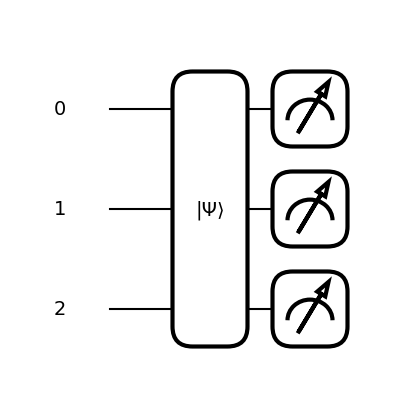

In [15]:
# Create a qnode
@qp.qnode(dev)
def circuit4():
  # add the template within the function and apply it on a specific set of wires
  qp.BasisEmbedding([0,1,0], wires=[0,1,2])

  # return a measurement
  return qp.probs()


# Draw your circuit
qp.draw_mpl(circuit4)();

array([0., 1.])

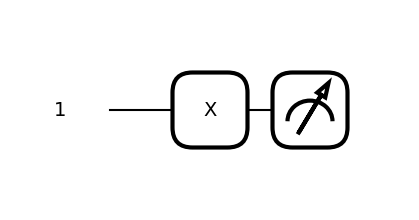

In [16]:
# You can decompose the template into different gate sets
#Decompose this circuit into Clifford + T gates
decomp = qp.decompose(circuit4, gate_set=qp.gate_sets.CLIFFORD_T)

# Draw your circuit
qp.draw_mpl(decomp, show_all_wires=True)()

# Run your circuit
decomp()
